In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

# import os
# for dirname, _, filenames in os.walk('/kaggle/input'):
#     for filename in filenames:
#         print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

In [2]:
import tensorflow as tf

# Data parameters
data_dir = 'Rice_Image_Dataset'
batch_size = 256
img_height = 224
img_width = 224
total_images = 75000

# Load the full dataset
full_ds = tf.keras.preprocessing.image_dataset_from_directory(
    data_dir,
    shuffle=True,
    seed=0,
    image_size=(img_height, img_width),
    batch_size=batch_size
)

# Save the class names before any splitting/transformations
class_names = full_ds.class_names

# Calculate counts for splits
train_count = int(0.8 * total_images)   # 60,000 images
val_count   = int(0.1 * total_images)     # 7,500 images
# Remaining images (7,500) for testing

# Number of batches (approximate)
train_batches = train_count // batch_size
val_batches   = val_count // batch_size

# Split the dataset
train_ds = full_ds.take(train_batches)
remaining_ds = full_ds.skip(train_batches)
val_ds = remaining_ds.take(val_batches)
test_ds = remaining_ds.skip(val_batches)

# Optimize datasets with caching to disk and prefetching
# AUTOTUNE = tf.data.AUTOTUNE
# train_ds = train_ds.cache("train_cache.tf-data").prefetch(buffer_size=AUTOTUNE)
# val_ds   = val_ds.cache("val_cache.tf-data").prefetch(buffer_size=AUTOTUNE)
# test_ds  = test_ds.cache("test_cache.tf-data").prefetch(buffer_size=AUTOTUNE)

# Now your dataset pipeline should be more memory efficient.


Found 75000 files belonging to 5 classes.


2025-03-11 19:21:59.366419: I metal_plugin/src/device/metal_device.cc:1154] Metal device set to: Apple M3
2025-03-11 19:21:59.366446: I metal_plugin/src/device/metal_device.cc:296] systemMemory: 16.00 GB
2025-03-11 19:21:59.366453: I metal_plugin/src/device/metal_device.cc:313] maxCacheSize: 5.33 GB
I0000 00:00:1741746119.367033  165716 pluggable_device_factory.cc:305] Could not identify NUMA node of platform GPU ID 0, defaulting to 0. Your kernel may not have been built with NUMA support.
I0000 00:00:1741746119.367079  165716 pluggable_device_factory.cc:271] Created TensorFlow device (/job:localhost/replica:0/task:0/device:GPU:0 with 0 MB memory) -> physical PluggableDevice (device: 0, name: METAL, pci bus id: <undefined>)


## Visualize the Data

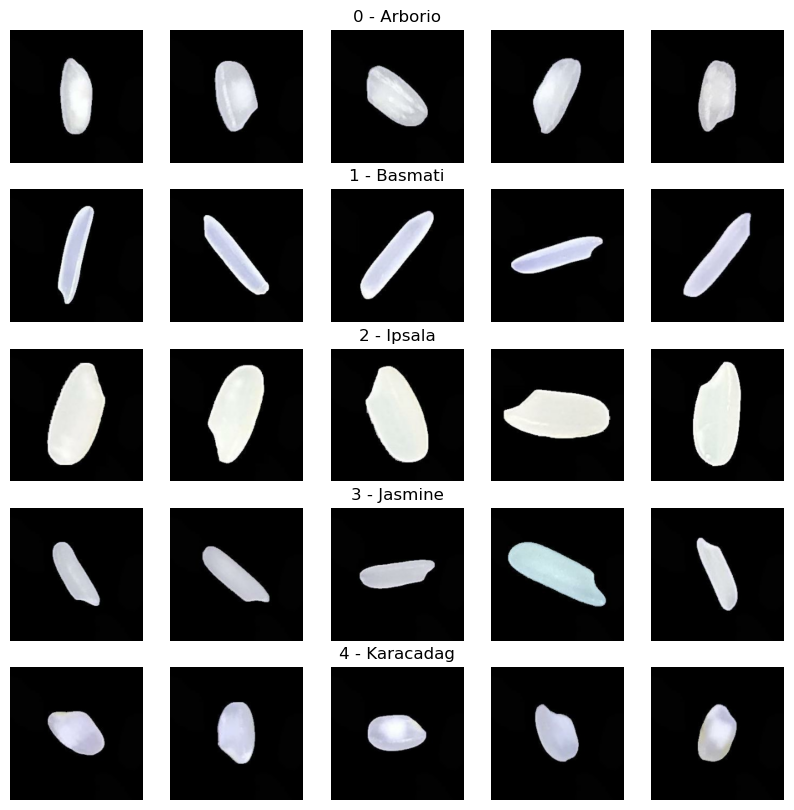

In [7]:
import matplotlib.pyplot as plt

# Create a figure for a 5x5 grid of images
plt.figure(figsize=(10, 10))

# Initialize a dictionary to store up to 5 images for each strain.
# Here we assume there are 5 strains labeled 0 to 4.
class_images = {i: [] for i in range(5)}

# Extract one batch from the training dataset and group images by label.
for images, labels in train_ds.take(1):
    for img, lbl in zip(images, labels):
        label_val = lbl.numpy()
        # Only collect 5 images per strain.
        if len(class_images[label_val]) < 5:
            class_images[label_val].append(img)

# Now create a 5x5 grid: each row corresponds to one strain.
row_index = 0
for label_val in sorted(class_images.keys()):
    for col_index in range(5):
        ax = plt.subplot(5, 5, row_index * 5 + col_index + 1)
        plt.imshow(class_images[label_val][col_index].numpy().astype("uint8"))
        # Display text only on the center image of the row (3rd column)
        if col_index == 2:
            plt.title(f"{label_val} - {class_names[label_val]}")
        plt.axis("off")
    row_index += 1

plt.savefig('training_images.jpg', format='jpg', dpi=300)
plt.show()


# Models

## Transfer Learning Model

In [ ]:
import tensorflow as tf
from tensorflow.keras.callbacks import EarlyStopping

# Transfer Learning Model: Using a pre-trained MobileNetV2 as an example
base_model = tf.keras.applications.MobileNetV2(
    input_shape=(img_height, img_width, 3),
    include_top=False,
    weights='imagenet'
)
base_model.trainable = False  # Freeze the base model

# Add a classification head on top
global_avg = tf.keras.layers.GlobalAveragePooling2D()(base_model.output)
output = tf.keras.layers.Dense(5, activation='softmax')(global_avg)  # 5 classes for rice varieties

model = tf.keras.Model(inputs=base_model.input, outputs=output)

model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

# Set up EarlyStopping callback to monitor validation loss and stop training if it doesn't improve
early_stop = EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)

# Train the model using training and validation sets, with early stopping included
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=10,  # Adjust as needed
    callbacks=[early_stop]
)

# Evaluate the model on the test set
test_loss, test_accuracy = model.evaluate(test_ds)
print(f"Test accuracy: {test_accuracy:.4f}")


Epoch 1/10


2025-03-11 18:36:18.079188: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:117] Plugin optimizer for device_type GPU is enabled.


234/234 ━━━━━━━━━━━━━━━━━━━━ 247s 1s/step - accuracy: 0.7713 - loss: 0.6516 - val_accuracy: 0.9558 - val_loss: 0.1604
Epoch 2/10
234/234 ━━━━━━━━━━━━━━━━━━━━ 249s 1s/step - accuracy: 0.9579 - loss: 0.1484 - val_accuracy: 0.9662 - val_loss: 0.1135
Epoch 3/10
234/234 ━━━━━━━━━━━━━━━━━━━━ 255s 1s/step - accuracy: 0.9671 - loss: 0.1103 - val_accuracy: 0.9705 - val_loss: 0.0947
Epoch 4/10
234/234 ━━━━━━━━━━━━━━━━━━━━ 292s 1s/step - accuracy: 0.9721 - loss: 0.0926 - val_accuracy: 0.9754 - val_loss: 0.0811
Epoch 5/10
234/234 ━━━━━━━━━━━━━━━━━━━━ 262s 1s/step - accuracy: 0.9738 - loss: 0.0849 - val_accuracy: 0.9767 - val_loss: 0.0755
Epoch 6/10
234/234 ━━━━━━━━━━━━━━━━━━━━ 251s 1s/step - accuracy: 0.9769 - loss: 0.0750 - val_accuracy: 0.9772 - val_loss: 0.0713
Epoch 7/10
234/234 ━━━━━━━━━━━━━━━━━━━━ 253s 1s/step - accuracy: 0.9779 - loss: 0.0699 - val_accuracy: 0.9803 - val_loss: 0.0652
Epoch 8/10
234/234 ━━━━━━━━━━━━━━━━━━━━ 255s 1s/step - accuracy: 0.9795 - loss: 0.0655 - val_accuracy: 0.979

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1 (Conv2D)      │ (None, 112, 112,  │        864 │ input_layer[0][0] │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn_Conv1            │ (None, 112, 112,  │        128 │ Conv1[0][0]       │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1_relu (ReLU)   │ (None, 112, 112,  │          0 │ bn_Conv1[0][0]    │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │        288 │ Conv1_relu[0][0]  │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │        128 │ expanded_conv_de… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │          0 │ expanded_conv_de… │
│ (ReLU)              │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │        512 │ expanded_conv_de… │
│ (Conv2D)            │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │         64 │ expanded_conv_pr… │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand      │ (None, 112, 112,  │      1,536 │ expanded_conv_pr… │
│ (Conv2D)            │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_BN   │ (None, 112, 112,  │        384 │ block_1_expand[0… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_relu │ (None, 112, 112,  │          0 │ block_1_expand_B… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_pad         │ (None, 113, 113,  │          0 │ block_1_expand_r… │
│ (ZeroPadding2D)     │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise   │ (None, 56, 56,    │        864 │ block_1_pad[0][0] │
│ (DepthwiseConv2D)   │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 56, 56,    │        384 │ block_1_depthwis… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 56, 56,    │          0 │ block_1_depthwis… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_project     │ (None, 56, 56,    │      2,304 │ block_1_depthwis

 Total params: 2,277,201 (8.69 MB)

 Trainable params: 6,405 (25.02 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

 Optimizer params: 12,812 (50.05 KB)

30/30 ━━━━━━━━━━━━━━━━━━━━ 36s 942ms/step - accuracy: 0.9856 - loss: 0.0481
Test accuracy: 0.9837


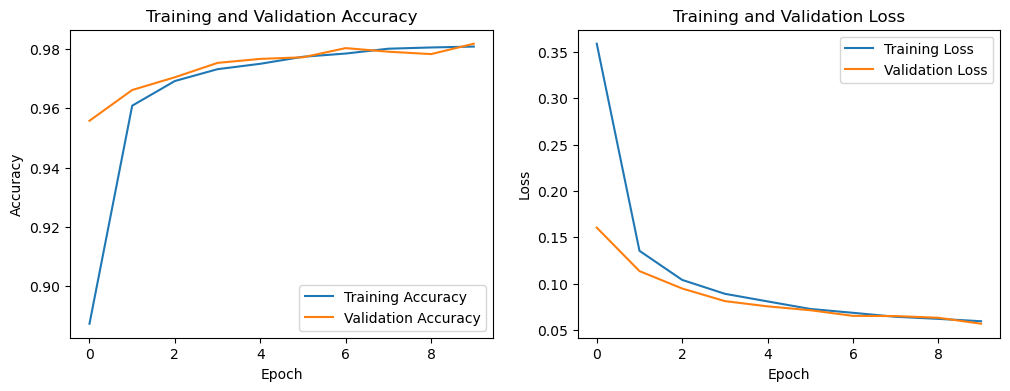

In [5]:
import matplotlib.pyplot as plt

# Plot accuracy
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend(loc='lower right')
plt.title('Training and Validation Accuracy')

# Plot loss
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend(loc='upper right')
plt.title('Training and Validation Loss')
plt.savefig('transfer_learning_accuracy.jpg', format='jpg', dpi=300)
plt.show()


8/8 ━━━━━━━━━━━━━━━━━━━━ 2s 112ms/step


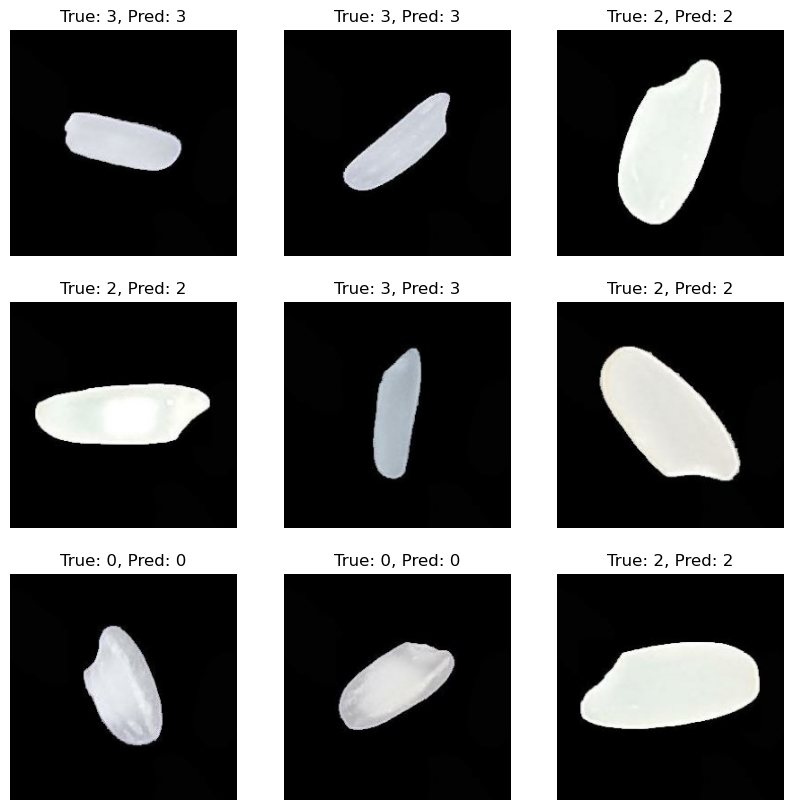

2025-03-11 19:19:56.904116: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


In [6]:
import numpy as np
import matplotlib.pyplot as plt

# Get a batch from the validation dataset
for images, labels in val_ds.take(1):
    predictions = model.predict(images)
    predicted_labels = np.argmax(predictions, axis=1)
    plt.figure(figsize=(10, 10))
    for i in range(9):
        ax = plt.subplot(3, 3, i + 1)
        plt.imshow(images[i].numpy().astype("uint8"))
        plt.title(f"True: {labels[i].numpy()}, Pred: {predicted_labels[i]}")
        plt.axis("off")
    plt.savefig('transfer_learning_results.jpg', format='jpg', dpi=300)
    plt.show()


In [7]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Collect all predictions and true labels from the validation set
all_preds = []
all_labels = []
for images, labels in test_ds:
    preds = model.predict(images)
    all_preds.extend(np.argmax(preds, axis=1))
    all_labels.extend(labels.numpy())

cm = confusion_matrix(all_labels, all_preds)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
disp.plot(cmap=plt.cm.Blues)
plt.title("Test Data Confusion Matrix")
plt.savefig('transfer_learning_matrix.jpg', format='jpg', dpi=300)
plt.show()


ModuleNotFoundError: No module named 'sklearn'

## Improved CNN Model

In [12]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import InputLayer, Conv2D, MaxPooling2D, GlobalAveragePooling2D, Dense, Dropout

# Define image dimensions and batch size
img_height = 224
img_width = 224
batch_size = 256

# Build an improved CNN model
model = Sequential([
    InputLayer(input_shape=(img_height, img_width, 3)),
    
    # Convolutional Block 1
    Conv2D(32, (3, 3), activation='relu', padding='same'),
    MaxPooling2D((2, 2)),
    
    # Convolutional Block 2
    Conv2D(64, (3, 3), activation='relu', padding='same'),
    MaxPooling2D((2, 2)),
    
    # Convolutional Block 3
    Conv2D(128, (3, 3), activation='relu', padding='same'),
    MaxPooling2D((2, 2)),
    
    # Global Average Pooling reduces the spatial dimensions to 1
    GlobalAveragePooling2D(),
    
    # A smaller dense layer for classification
    Dense(128, activation='relu'),
    Dropout(0.5),
    Dense(5, activation='softmax')  # 5 output classes for your rice varieties
])

# Compile the model
model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

# Set up EarlyStopping to avoid overfitting
early_stop = tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)

# Train the model using the training and validation datasets
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=10,  # Adjust epochs as needed
    callbacks=[early_stop]
)

# Print the model summary for a quick review
model.summary()

# Evaluate the model on the test dataset
test_loss, test_accuracy = model.evaluate(test_ds)
print(f"Test accuracy: {test_accuracy:.4f}")


Epoch 1/10


2025-03-10 20:22:10.690709: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:114] Plugin optimizer for device_type GPU is enabled.


234/234 [==============================] - ETA: 0s - loss: 1.4031 - accuracy: 0.4904

2025-03-10 20:25:55.125630: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:114] Plugin optimizer for device_type GPU is enabled.


234/234 [==============================] - 236s 1s/step - loss: 1.4031 - accuracy: 0.4904 - val_loss: 0.3047 - val_accuracy: 0.8710
Epoch 2/10
234/234 [==============================] - 238s 1s/step - loss: 0.2562 - accuracy: 0.9082 - val_loss: 0.0777 - val_accuracy: 0.9767
Epoch 3/10
234/234 [==============================] - 239s 1s/step - loss: 0.0974 - accuracy: 0.9669 - val_loss: 0.0453 - val_accuracy: 0.9830
Epoch 4/10
234/234 [==============================] - 237s 1s/step - loss: 0.1736 - accuracy: 0.9481 - val_loss: 0.0375 - val_accuracy: 0.9868
Epoch 5/10
234/234 [==============================] - 240s 1s/step - loss: 0.1121 - accuracy: 0.9628 - val_loss: 0.0255 - val_accuracy: 0.9899
Epoch 6/10
234/234 [==============================] - 242s 1s/step - loss: 0.0624 - accuracy: 0.9790 - val_loss: 0.1044 - val_accuracy: 0.9605
Epoch 7/10
234/234 [==============================] - 240s 1s/step - loss: 0.0515 - accuracy: 0.9832 - val_loss: 0.0180 - val_accuracy: 0.9941
Epoch 8/10

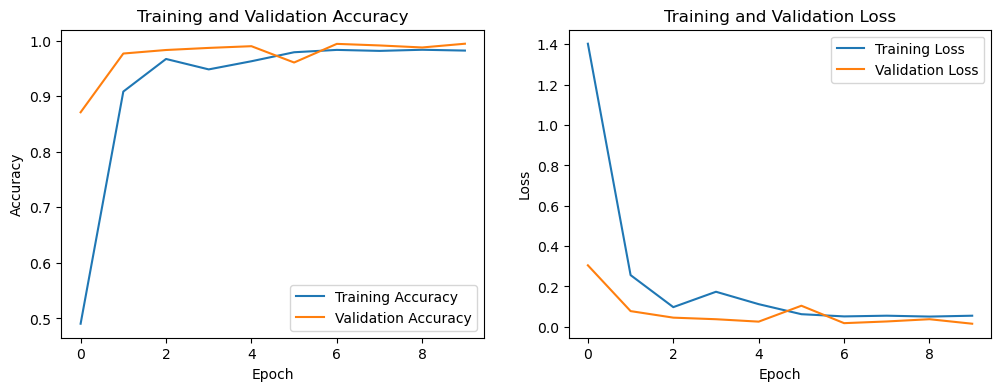

In [13]:
# Assuming `history` is the output from model.fit
import matplotlib.pyplot as plt

# Plot accuracy
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend(loc='lower right')
plt.title('Training and Validation Accuracy')

# Plot loss
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend(loc='upper right')
plt.title('Training and Validation Loss')
plt.savefig('cnn_improved_accuracy.jpg', format='jpg', dpi=300)
plt.show()


2025-03-10 21:02:10.421069: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INVALID_ARGUMENT: You must feed a value for placeholder tensor 'Placeholder/_0' with dtype string and shape [75000]
	 [[{{node Placeholder/_0}}]]
2025-03-10 21:02:10.421412: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INVALID_ARGUMENT: You must feed a value for placeholder tensor 'Placeholder/_4' with dtype int32 and shape [75000]
	 [[{{node Placeholder/_4}}]]


8/8 [==============================] - 0s 18ms/step


2025-03-10 21:02:18.357221: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:114] Plugin optimizer for device_type GPU is enabled.


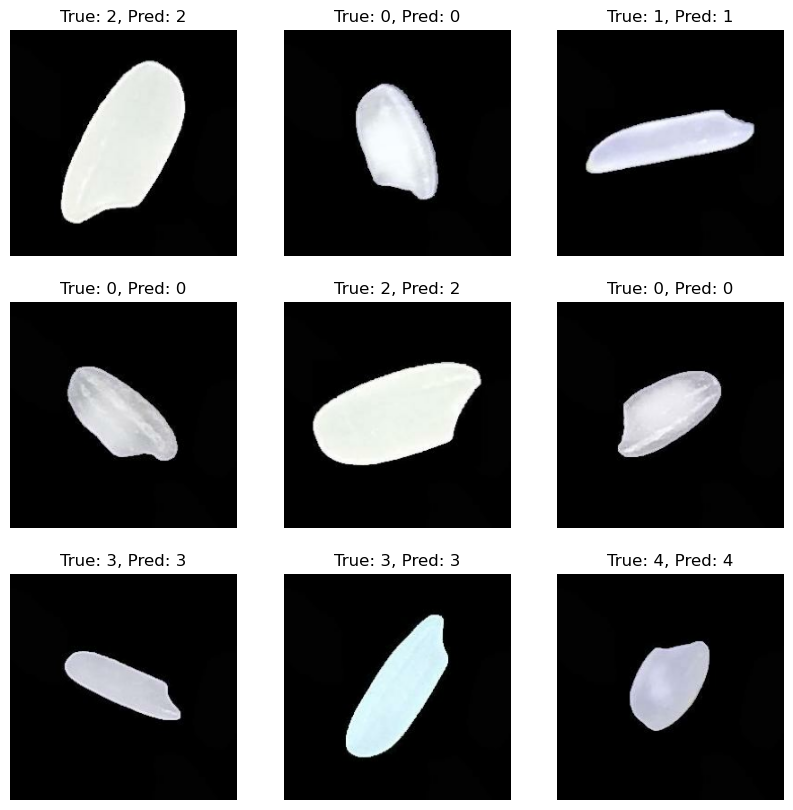

In [14]:
import numpy as np
import matplotlib.pyplot as plt

# Get a batch from the validation dataset
for images, labels in val_ds.take(1):
    predictions = model.predict(images)
    predicted_labels = np.argmax(predictions, axis=1)
    plt.figure(figsize=(10, 10))
    for i in range(9):
        ax = plt.subplot(3, 3, i + 1)
        plt.imshow(images[i].numpy().astype("uint8"))
        plt.title(f"True: {labels[i].numpy()}, Pred: {predicted_labels[i]}")
        plt.axis("off")
    plt.savefig('cnn_improved_results.jpg', format='jpg', dpi=300)
    plt.show()


8/8 [==============================] - 0s 24ms/step


2025-03-10 21:02:33.817840: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:114] Plugin optimizer for device_type GPU is enabled.


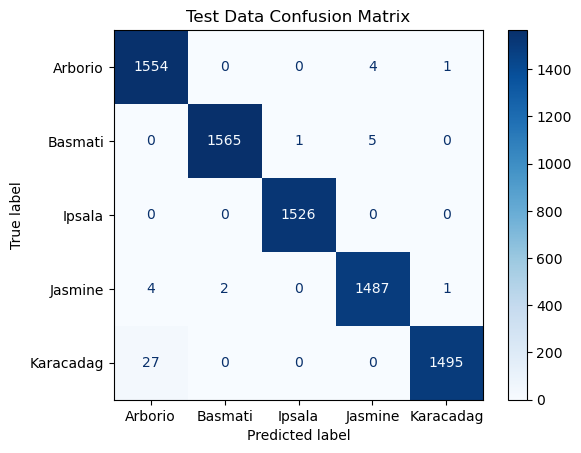

In [15]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Collect all predictions and true labels from the validation set
all_preds = []
all_labels = []
for images, labels in test_ds:
    preds = model.predict(images)
    all_preds.extend(np.argmax(preds, axis=1))
    all_labels.extend(labels.numpy())

cm = confusion_matrix(all_labels, all_preds)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
disp.plot(cmap=plt.cm.Blues)
plt.title("Test Data Confusion Matrix")
plt.savefig('cnn_imporved_matrix.jpg', format='jpg', dpi=300)
plt.show()


## Potential Next Steps

1. **Targeted Data Augmentation**  
   - **Class-Specific Augmentation:** If Karacadag and Arborio are often confused, try augmenting those classes more aggressively (e.g., brightness, contrast, rotations).  
   - **Focus on Distinguishing Features:** If grain shape or color is key, consider augmentations that preserve or highlight those differences (e.g., zooming in).

2. **Collect More Examples**  
   - If possible, gather additional or higher-resolution images specifically for the confusing pairs (Arborio vs. Karacadag, Basmati vs. Jasmine). More diverse images can help the model learn finer distinctions.

3. **Fine-Tuning the Transfer Learning Model**  
   - If you want the transfer learning model to catch up to or surpass the CNN’s performance, unfreeze more layers in the pre-trained network and train at a lower learning rate. This sometimes helps the model learn domain-specific details.

4. **Experiment with Other Architectures**  
   - Try different backbones (e.g., EfficientNet, ResNet) or experiment with a deeper custom CNN. Sometimes a slightly more complex architecture can capture subtle class differences better.

5. **Feature Engineering (If Applicable)**  
   - If you have the option to measure grain length or other morphological features (outside pure image data), combining them with the CNN’s predictions can help disambiguate visually similar varieties.